In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math


# Phase - 1

## Data Exploratory analysis - ( import dataset )

In [2]:
cust_bh = pd.read_excel(r"CustomerBehaviorData.xlsx")
cust_dom = pd.read_excel(r"CustomerDemographics.xlsx")
cust_con = pd.read_excel(r"CreditConsumptiondata.xlsx")


In [3]:
merge1 = pd.merge(cust_con,cust_bh , on= 'ID' , how = 'left')

credit_cc  = pd.merge(merge1, cust_dom , on='ID' , how = 'left')

In [4]:
credit_cc.head(5)

,ID,cc_cons,cc_cons_apr,dc_cons_apr,cc_cons_may,dc_cons_may,cc_cons_jun,dc_cons_jun,cc_count_apr,cc_count_may,...,emi_active,account_type,gender,age,Income,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction
0,17051,16239.0,2017.46,29066.66,15919.84,2197.00,3752.000,29798.00,1.0,4,...,3448.84,current,M,30,MEDIUM,26.4,9,9,355,0
1,11491,39002.0,7687.00,1308.00,41888.92,2216.92,7060.530,3143.36,2.0,27,...,3812.69,current,M,37,LOW,14.4,7,7,485,0
2,7433,21182.0,9094.46,14825.95,3087.64,769.59,25602.595,1445.00,44.0,8,...,9432.90,current,M,33,MEDIUM,3.2,1,1,764,0
3,14606,8123.0,3126.00,4616.33,8676.80,5923.00,6717.000,18747.00,4.0,30,...,144.61,current,M,63,LOW,10.2,6,6,863,0
4,8381,28282.0,24988.72,10091.23,10132.00,3477.00,4667.000,511.00,2.0,8,...,1887.89,saving,M,33,MEDIUM,26.4,6,6,523,0


In [5]:
credit_cc.select_dtypes('object')

,loan_enq,account_type,gender,Income
0,Y,current,M,MEDIUM
1,Y,current,M,LOW
2,Y,current,M,MEDIUM
3,Y,current,M,LOW
4,Y,saving,M,MEDIUM
...,...,...,...,...
19995,Y,current,M,MEDIUM
19996,Y,current,M,MEDIUM
19997,Y,current,M,HIGH
19998,Y,current,M,MEDIUM


In [6]:
credit_cc.describe()

,ID,cc_cons,cc_cons_apr,dc_cons_apr,cc_cons_may,dc_cons_may,cc_cons_jun,dc_cons_jun,cc_count_apr,cc_count_may,...,credit_count_jun,debit_count_jun,max_credit_amount_jun,emi_active,age,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction
count,20000.000000,15000.000000,20000.000000,20000.000000,1.999900e+04,19999.000000,20000.000000,19999.000000,19999.000000,20000.000000,...,20000.000000,20000.000000,2.000000e+04,1.999900e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,9369.030957,17856.990922,8130.453413,1.618836e+04,7702.123897,12135.806021,7109.708341,41.611631,33.569100,...,19.905450,44.529100,5.284985e+04,1.539887e+04,47.672300,15.217250,5.496050,5.496050,598.929400,0.718000
std,5773.647028,7552.997163,25158.878234,14572.188829,2.651068e+04,17893.127746,18790.984789,13313.935609,97.835475,50.316925,...,27.055323,35.080453,1.343175e+05,1.202541e+05,30.359771,20.481455,2.870452,2.870452,220.140472,0.449985
min,0.000000,610.099000,253.000000,19.350000,1.570000e+02,22.000000,65.000000,62.000000,1.000000,1.000000,...,1.000000,0.000000,6.000000e-02,0.000000e+00,25.000000,0.500000,1.000000,1.000000,0.000000,0.000000
25%,4999.750000,4808.621700,4377.000000,1624.650000,3.635910e+03,1634.260000,2999.075000,1361.100000,5.000000,8.000000,...,4.000000,12.000000,1.896450e+04,1.545940e+03,33.000000,5.100000,3.000000,3.000000,424.000000,0.000000
50%,9999.500000,7408.604400,10214.642500,3964.750000,8.635230e+03,3791.720000,6656.800000,3326.000000,10.000000,23.000000,...,7.000000,37.000000,3.025000e+04,3.934660e+03,40.000000,9.900000,6.000000,6.000000,623.000000,1.000000
75%,14999.250000,11518.832800,21189.000000,9339.020000,1.865531e+04,8263.590000,14195.727500,7458.820000,44.000000,43.000000,...,21.000000,73.000000,5.344900e+04,9.376390e+03,53.000000,18.000000,8.000000,8.000000,799.000000,1.000000
max,19999.000000,160735.934800,441031.330000,229255.000000,1.117246e+06,911223.490000,382914.100000,233384.000000,531.000000,601.000000,...,117.000000,133.000000,5.200000e+06,7.447125e+06,223.000000,203.000000,10.000000,10.000000,974.000000,1.000000


In [7]:
credit_cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   cc_cons                       15000 non-null  float64
 2   cc_cons_apr                   20000 non-null  float64
 3   dc_cons_apr                   20000 non-null  float64
 4   cc_cons_may                   19999 non-null  float64
 5   dc_cons_may                   19999 non-null  float64
 6   cc_cons_jun                   20000 non-null  float64
 7   dc_cons_jun                   19999 non-null  float64
 8   cc_count_apr                  19999 non-null  float64
 9   cc_count_may                  20000 non-null  int64  
 10  cc_count_jun                  20000 non-null  int64  
 11  dc_count_apr                  20000 non-null  int64  
 12  dc_count_may                  20000 non-null  int64  
 13  d

In [8]:
credit_data = credit_cc.isna().sum()
summary_credit  = credit_data[credit_data > 0]
print(summary_credit)

cc_cons                 5000
cc_cons_may                1
dc_cons_may                1
dc_cons_jun                1
cc_count_apr               1
personal_loan_closed       1
investment_3               2
debit_count_apr            1
loan_enq                   2
emi_active                 1
dtype: int64


In [9]:
duplicate  = credit_cc.duplicated()
print(duplicate.sum())

# here hence prove that dataset has not any duplicate rows

0


# Tranform  ( Data cleaning and filling null values)

In [10]:
## Handling missing values in dataset  

In [11]:

missing_values  = credit_cc.isna().sum() 
summary_missing = missing_values[missing_values>0]
print(summary_missing)


cc_cons                 5000
cc_cons_may                1
dc_cons_may                1
dc_cons_jun                1
cc_count_apr               1
personal_loan_closed       1
investment_3               2
debit_count_apr            1
loan_enq                   2
emi_active                 1
dtype: int64


In [12]:
# Fill the missing values  expact  cc_cons


In [13]:
cols_to_fix  = ['cc_cons_may','dc_cons_may' , 'dc_cons_jun' , 'cc_count_apr' ,'investment_3' , 'debit_count_apr' ,'emi_active']
credit_cc[cols_to_fix] = credit_cc[cols_to_fix].fillna(credit_cc[cols_to_fix].mean())

In [14]:

col2  = ['loan_enq' , 'personal_loan_closed','Income']
credit_cc[col2] = credit_cc[col2].fillna(credit_cc[col2].mode().iloc[0])

In [15]:

missing_value  = credit_cc.isna().sum() 
summary_mis = missing_value[missing_value>0]
print(summary_mis)


cc_cons    5000
dtype: int64


In [16]:
credit_cc.columns

Index(['ID', 'cc_cons', 'cc_cons_apr', 'dc_cons_apr', 'cc_cons_may',
       'dc_cons_may', 'cc_cons_jun', 'dc_cons_jun', 'cc_count_apr',
       'cc_count_may', 'cc_count_jun', 'dc_count_apr', 'dc_count_may',
       'dc_count_jun', 'card_lim', 'personal_loan_active',
       'vehicle_loan_active', 'personal_loan_closed', 'vehicle_loan_closed',
       'investment_1', 'investment_2', 'investment_3', 'investment_4',
       'debit_amount_apr', 'credit_amount_apr', 'debit_count_apr',
       'credit_count_apr', 'max_credit_amount_apr', 'debit_amount_may',
       'credit_amount_may', 'credit_count_may', 'debit_count_may',
       'max_credit_amount_may', 'debit_amount_jun', 'credit_amount_jun',
       'credit_count_jun', 'debit_count_jun', 'max_credit_amount_jun',
       'loan_enq', 'emi_active', 'account_type', 'gender', 'age', 'Income',
       'Emp_Tenure_Years', 'Tenure_with_Bank', 'region_code',
       'NetBanking_Flag', 'Avg_days_between_transaction'],
      dtype='object')

In [17]:
# summing the all the transaction , count , times & max credit are group intro cleaning the reformat them

credit_cc['total_spend_credit_cc'] = credit_cc[['cc_cons_apr','cc_cons_jun','cc_cons_may']].sum(axis=1)
credit_cc['total_spend_debit_cc']  = credit_cc[['dc_cons_apr' ,'dc_cons_may' , 'dc_cons_jun']].sum(axis=1)
credit_cc['total_count_credit_trans'] = credit_cc[['cc_count_apr','cc_count_may','cc_count_jun']].sum(axis=1)
credit_cc['total_count_debit_trans']  = credit_cc[['dc_count_apr','dc_count_may','dc_count_jun']].sum(axis=1)
credit_cc['total_investment'] =  credit_cc[['investment_1','investment_2','investment_3','investment_4']].sum(axis=1)
credit_cc['total_sum_debited_amount'] = credit_cc[['debit_amount_apr', 'debit_amount_may','debit_amount_jun']].sum(axis=1)
credit_cc['total_sum_credited_amount']  = credit_cc[['credit_amount_apr','credit_amount_may','credit_amount_jun']].sum(axis=1)
credit_cc['total_count_debited_counts']  =credit_cc[['debit_count_apr','debit_count_may','debit_count_jun']].sum(axis=1)
credit_cc['total_count_credited_counts'] =credit_cc[['credit_count_apr','credit_count_may','credit_count_jun']].sum(axis=1)
credit_cc['total_max_credited_amount'] = credit_cc[['max_credit_amount_apr','max_credit_amount_may','max_credit_amount_jun']].sum(axis=1)

In [18]:
credit_cc.drop(columns= ['cc_cons_apr', 'dc_cons_apr', 'cc_cons_may',
       'dc_cons_may', 'cc_cons_jun', 'dc_cons_jun', 'cc_count_apr',
       'cc_count_may', 'cc_count_jun', 'dc_count_apr', 'dc_count_may',
       'dc_count_jun','investment_1', 'investment_2', 'investment_3', 'investment_4',
       'debit_amount_apr', 'credit_amount_apr', 'debit_count_apr',
       'credit_count_apr', 'max_credit_amount_apr', 'debit_amount_may',
       'credit_amount_may', 'credit_count_may', 'debit_count_may',
       'max_credit_amount_may', 'debit_amount_jun', 'credit_amount_jun',
       'credit_count_jun', 'debit_count_jun', 'max_credit_amount_jun',],inplace=True)

In [19]:
print(" --------------------------------------------------------------------------------")
print("shape of dataset" , credit_cc.shape)
print("---------------------------------------------------------------------------------")
print("information of dataset is" , credit_cc.info())
print("---------------------------------------------------------------------------------")
print("Describe of the dataset" , credit_cc.describe())
print("----------------------------------------------------------------------------------")

 --------------------------------------------------------------------------------
shape of dataset (20000, 28)
---------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   cc_cons                       15000 non-null  float64
 2   card_lim                      20000 non-null  int64  
 3   personal_loan_active          20000 non-null  int64  
 4   vehicle_loan_active           20000 non-null  int64  
 5   personal_loan_closed          20000 non-null  float64
 6   vehicle_loan_closed           20000 non-null  int64  
 7   loan_enq                      20000 non-null  object 
 8   emi_active                    20000 non-null  float64
 9   account_type                  20000 non-null

### Outlier Treatment Strategy
Data Preprocessing Observations:

  - Approximately 80% of the columns exhibit outliers.
  - Columns like age and tenure of emp show extreme outliers.
  - Action Plan: We will perform outlier removal and capping to ensure the data is consistent and robust for modeling.

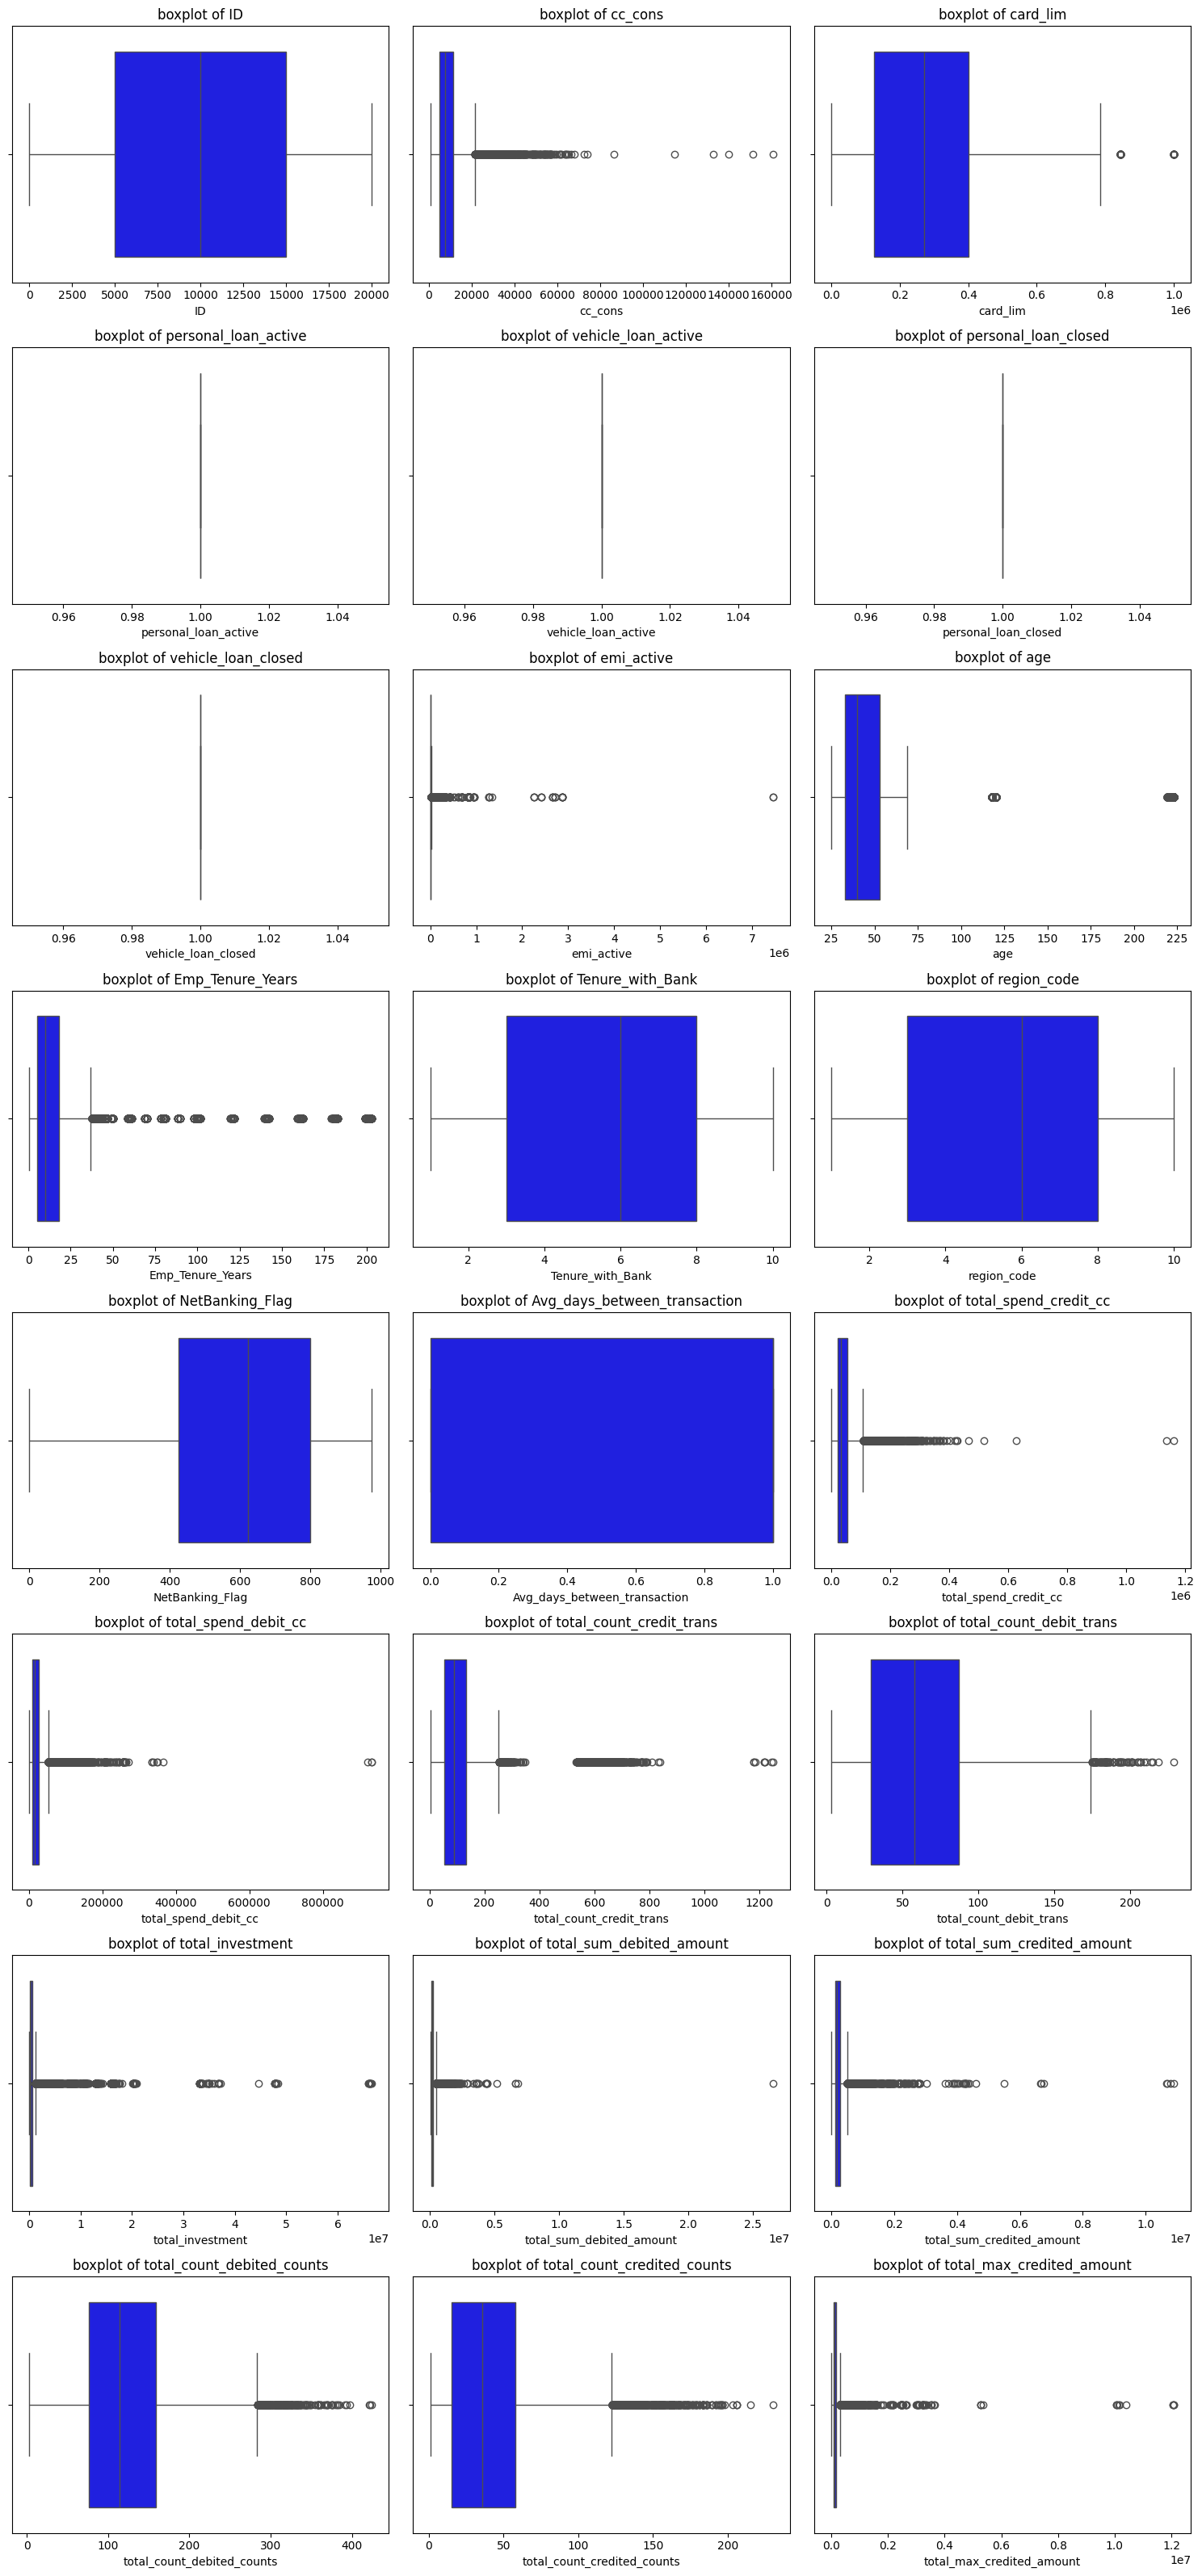

In [20]:
import math

# Get the list of columns
numerical_cols = credit_cc.select_dtypes(include=['int', 'float']).columns

# Set up the grid dimensions (3 columns per row)
cols_per_row = 3
n_rows = math.ceil(len(numerical_cols) / cols_per_row)

# Set the overall figure size
plt.figure(figsize=(15, n_rows * 4))

for i, cols in enumerate(numerical_cols):
    # This creates the 3-wide grid layout
    plt.subplot(n_rows, cols_per_row, i + 1)
    
    # original plotting logic (added orient='h' for horizontal)
    sns.boxplot(x=credit_cc[cols], color='blue')
    plt.title(f'boxplot of {cols}')

plt.tight_layout()
plt.show()

### I have create outlier def function to cap the extreme values in columns make data skewed distribution

In [21]:
def outlier_capp(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 -Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return np.where(series < lower,lower,np.where (series > upper , upper , series))

In [22]:
credit_cc.columns

Index(['ID', 'cc_cons', 'card_lim', 'personal_loan_active',
       'vehicle_loan_active', 'personal_loan_closed', 'vehicle_loan_closed',
       'loan_enq', 'emi_active', 'account_type', 'gender', 'age', 'Income',
       'Emp_Tenure_Years', 'Tenure_with_Bank', 'region_code',
       'NetBanking_Flag', 'Avg_days_between_transaction',
       'total_spend_credit_cc', 'total_spend_debit_cc',
       'total_count_credit_trans', 'total_count_debit_trans',
       'total_investment', 'total_sum_debited_amount',
       'total_sum_credited_amount', 'total_count_debited_counts',
       'total_count_credited_counts', 'total_max_credited_amount'],
      dtype='object')

In [23]:
data  = ['total_spend_credit_cc', 'total_spend_debit_cc',
       'total_count_credit_trans', 'total_count_debit_trans',
       'total_investment', 'total_sum_debited_amount',
       'total_sum_credited_amount', 'total_count_debited_counts',
       'total_count_credited_counts', 'total_max_credited_amount']
for out in data:
    credit_cc[out] = outlier_capp(credit_cc[out])

In [24]:
numerical_col  = ['age' , 'Emp_Tenure_Years']

for col in numerical_col :
      credit_cc[col] = outlier_capp(credit_cc[col])

In [25]:
print(credit_cc['age'].max())
print(credit_cc['Emp_Tenure_Years'].max())


83.0
37.349999999999994


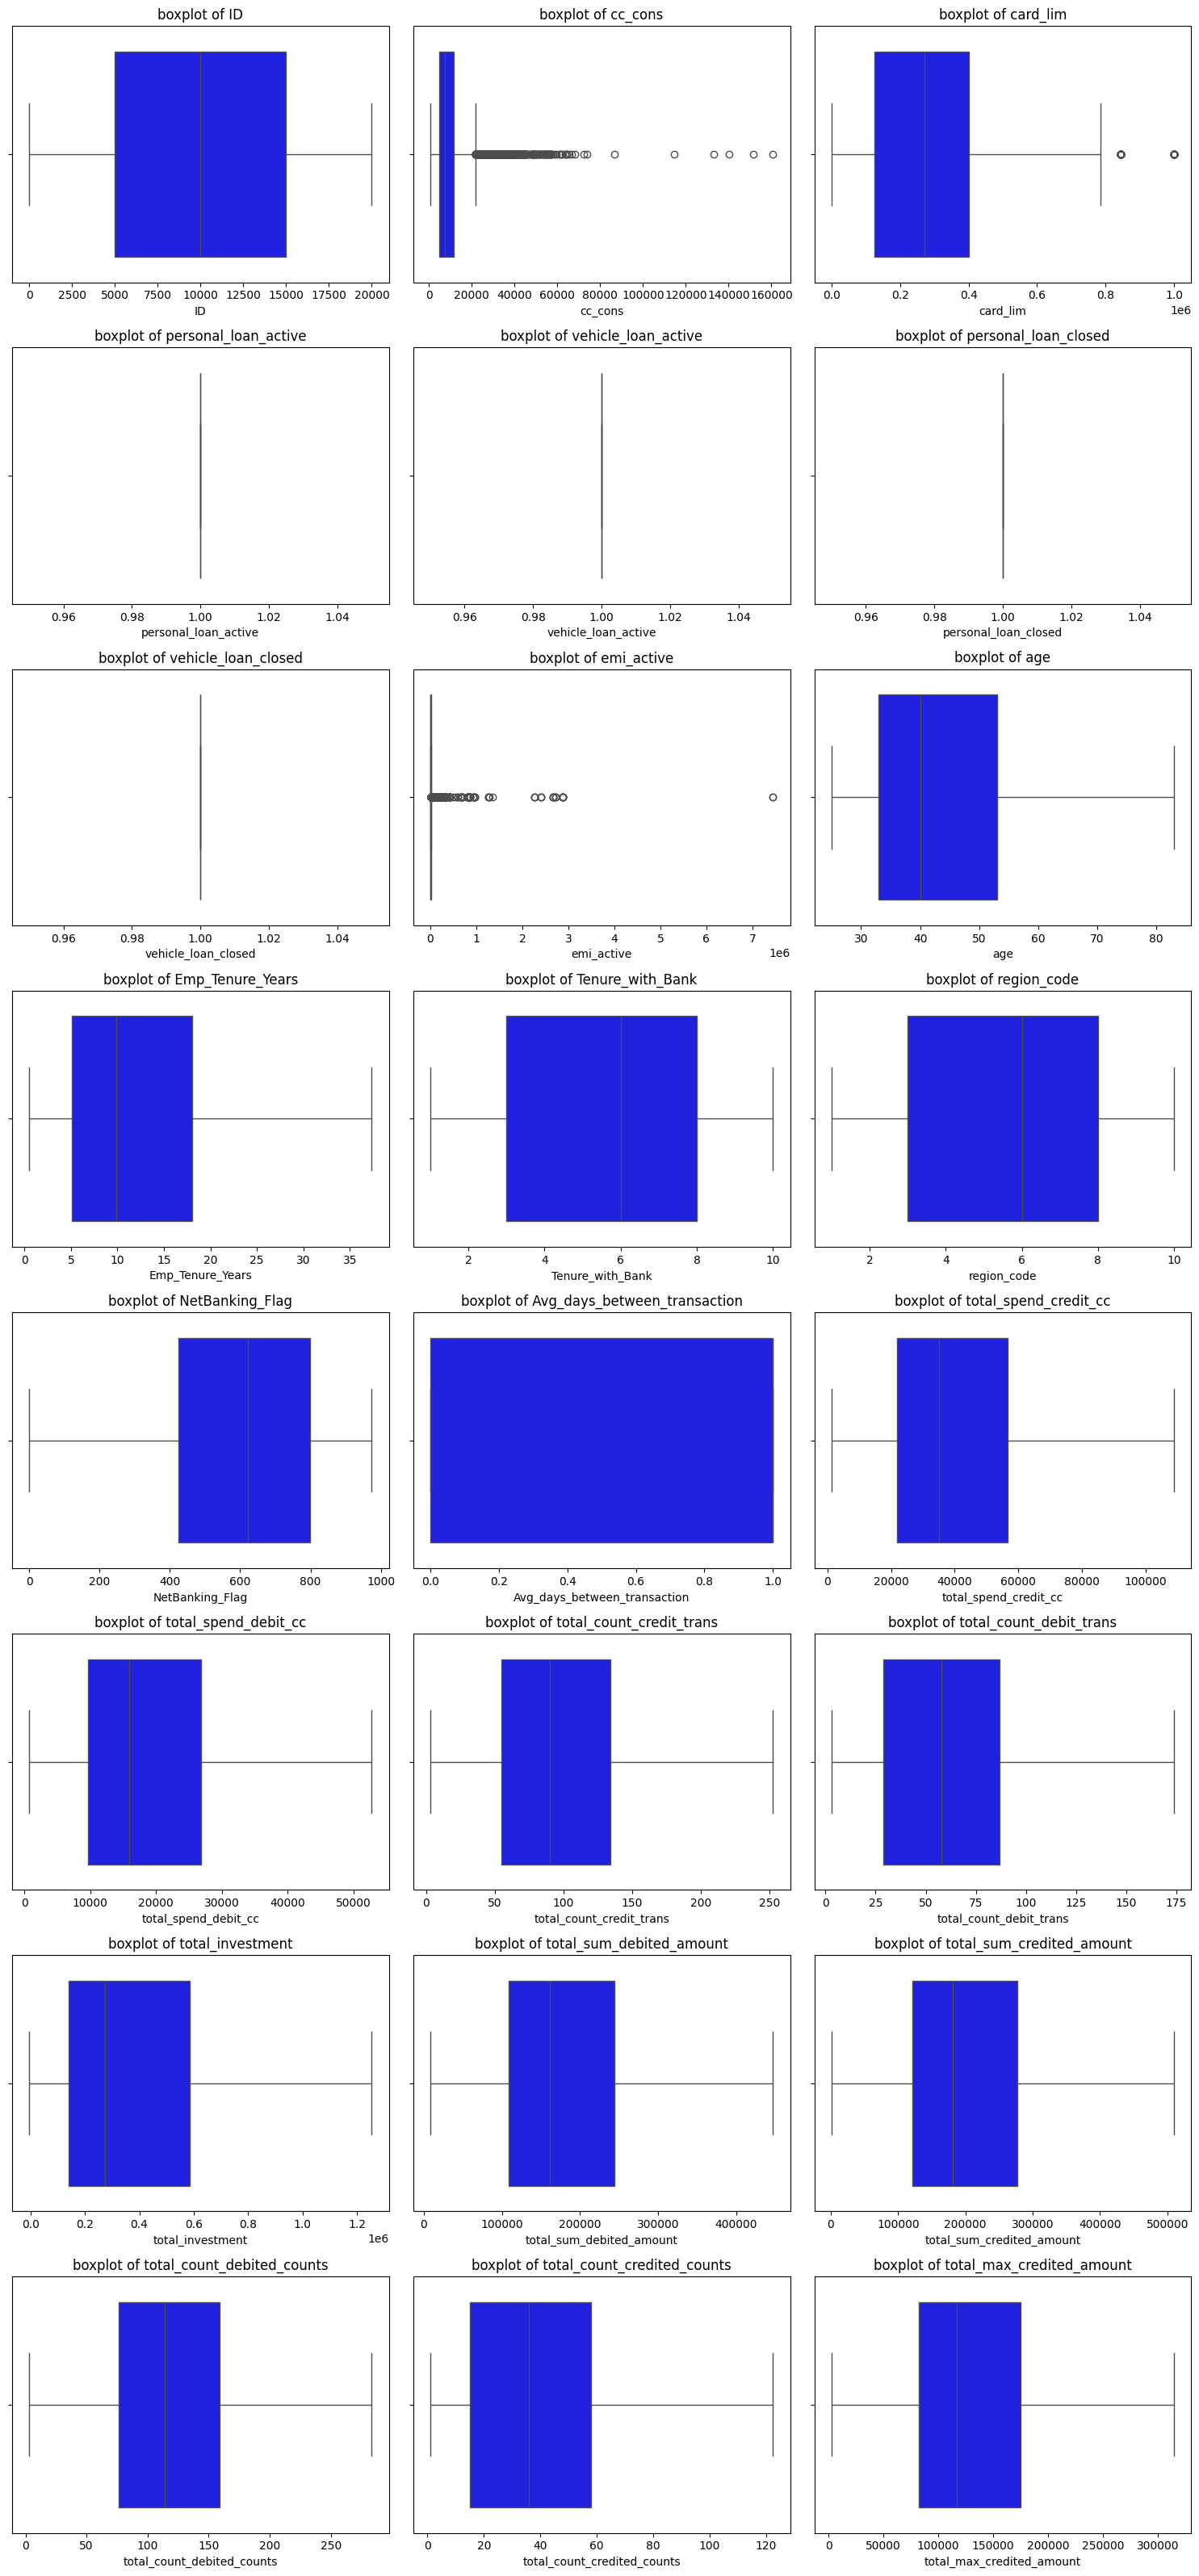

In [26]:
numerical_col = credit_cc.select_dtypes(include =['int','float']).columns
cols_per_rows = 3
n_rows = math.ceil(len(numerical_col) / cols_per_rows)

# Set the overall figure size
plt.figure(figsize=(15, n_rows * 4))

for i, cols in enumerate(numerical_col):
    # This creates the 3-wide grid layout
    plt.subplot(n_rows, cols_per_rows, i + 1)

    sns.boxplot(x=credit_cc[cols], color='blue')
    plt.title(f'boxplot of {cols}')

plt.tight_layout()
plt.show()

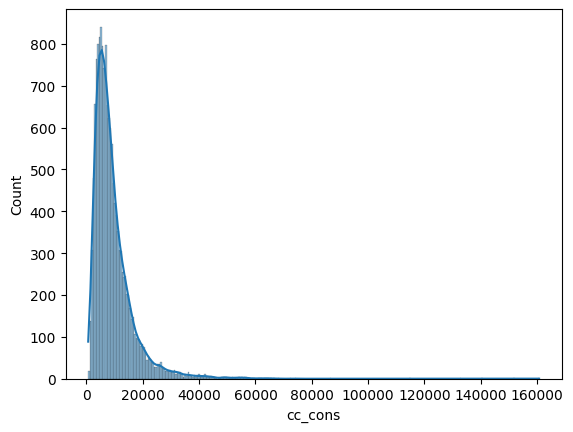

In [27]:
sns.histplot(credit_cc['cc_cons'] , kde=True)
plt.show()

## Analysis of Target Distribution:
As seen in the histogram above, the average credit card consumption (cc_cons) follows a heavy right-skewed distribution. Approximately 90% of customers have relatively low spending patterns, while the top 10% represent high-value spenders.

The Problem: > These extreme outliers create a "long tail" that prevents the model from accurately learning the patterns of the majority of the dataset. If left unaddressed, the model will prioritize minimizing the massive errors from these outliers, leading to poor generalization.

The Solution: > To improve model stability and reduce the overall error rate, we will cap the outliers at the 99th percentile. This process (Winsorization) "smooths" the distribution and ensures that extreme values do not disproportionately influence the model's performance.

In [28]:
# identify the 99th percentile 
cap_limit  = credit_cc['cc_cons'].quantile(0.99)

# apply capping 
credit_cc['cc_cons'] = credit_cc['cc_cons'].clip(upper=cap_limit)


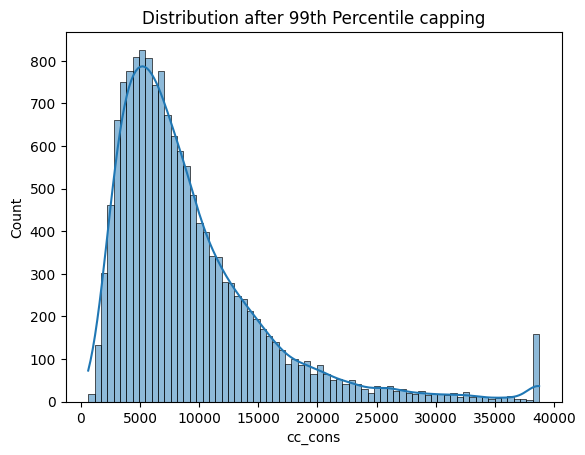

In [29]:
sns.histplot(credit_cc['cc_cons'] , kde=True)
plt.title('Distribution after 99th Percentile capping')
plt.show()

In [30]:
credit_cc.columns

Index(['ID', 'cc_cons', 'card_lim', 'personal_loan_active',
       'vehicle_loan_active', 'personal_loan_closed', 'vehicle_loan_closed',
       'loan_enq', 'emi_active', 'account_type', 'gender', 'age', 'Income',
       'Emp_Tenure_Years', 'Tenure_with_Bank', 'region_code',
       'NetBanking_Flag', 'Avg_days_between_transaction',
       'total_spend_credit_cc', 'total_spend_debit_cc',
       'total_count_credit_trans', 'total_count_debit_trans',
       'total_investment', 'total_sum_debited_amount',
       'total_sum_credited_amount', 'total_count_debited_counts',
       'total_count_credited_counts', 'total_max_credited_amount'],
      dtype='object')

In [31]:
credit_cc.head(3)

,ID,cc_cons,card_lim,personal_loan_active,vehicle_loan_active,personal_loan_closed,vehicle_loan_closed,loan_enq,emi_active,account_type,...,total_spend_credit_cc,total_spend_debit_cc,total_count_credit_trans,total_count_debit_trans,total_investment,total_sum_debited_amount,total_sum_credited_amount,total_count_debited_counts,total_count_credited_counts,total_max_credited_amount
0,17051,16239.000000,345000,1,1,1.0,1,Y,3448.84,current,...,21689.300,52786.44875,40.0,21.0,279163.74,80872.59000,154165.000,99.0,119.0,314811.125
1,11491,38751.599102,369000,1,1,1.0,1,Y,3812.69,current,...,56636.450,6668.28000,79.0,19.0,324602.05,115870.46000,510021.065,22.0,9.0,173429.000
2,7433,21182.000000,27000,1,1,1.0,1,Y,9432.90,current,...,37784.695,17040.54000,99.0,32.0,254063.90,447164.94625,510021.065,134.0,12.0,215418.000


# KPIs
       1.credit Utilization Ratio
       2.Digital Engagement score
       3.Credit to Debit spend ratio
       4.average Transaction values
       5.inflow to outflow coverage
       6.loan burden index 
       7.Investment propensity
       8.Transaction Velocity
       9.wallet share index
       10.Customer Tenure value (ctv)

In [32]:
#1.credit Utilization Ratio

utilization  = credit_cc['total_spend_credit_cc'].sum() / credit_cc['card_lim'].sum()

print(f' Average Credit Utilization Ratio {utilization:.2%}')


 Average Credit Utilization Ratio 15.36%


In [33]:
#2.Digital Engagement score
digital = credit_cc['NetBanking_Flag'].mean()

print(f'Digital Engagement Score: {digital.round(2)}')

Digital Engagement Score: 598.93


In [34]:
#3.Credit to Debit spend ratio
spend_ratio = credit_cc['total_spend_credit_cc'].sum() / credit_cc['total_spend_debit_cc'].sum()
print(f'Credit to Debit Ratio: {spend_ratio:.2f}')

Credit to Debit Ratio: 2.11


In [35]:
#4.average Transaction values

total_spends  = credit_cc['total_spend_credit_cc'].sum() + credit_cc['total_spend_debit_cc'].sum()
total_count  =  credit_cc['total_count_credit_trans'].sum() + credit_cc['total_count_debit_trans'].sum()

ATV  =  total_spends / total_count

print(f'Average Credit trans values : {ATV.round(2)}')


Average Credit trans values : 388.4


In [36]:
#5.inflow to outflow coverage

in_to_out = credit_cc['total_sum_credited_amount'].sum() / credit_cc['total_sum_debited_amount'].sum()

print(f' inflow to outflow coverage to measures the liquidity and financial health of the customers : { in_to_out.round(2)}')

 inflow to outflow coverage to measures the liquidity and financial health of the customers : 1.13


In [37]:
#6.loan burden index

loan_burden_index = credit_cc['personal_loan_active'] + \
                    credit_cc['vehicle_loan_active'] + \
                   (credit_cc['emi_active']>0).astype(int)
avg = loan_burden_index.mean()

print(f'Average loan burden per customer : {avg.round(2)}')

Average loan burden per customer : 3.0


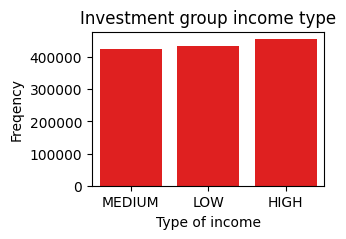

In [38]:
#7.Investment by groupy income tire 
mask = credit_cc['Income'].isin(['HIGH' , 'MEDIUM','LOW'])
invest_by_tier = credit_cc[mask].groupby('Income')['total_investment'].mean().sort_values()

plt.figure(figsize=(3,2))
sns.barplot(x=invest_by_tier.index , y=invest_by_tier.values , color = 'red')
plt.title("Investment group income type")
plt.xlabel("Type of income")
plt.ylabel("Freqency")
plt.show()

In [39]:
#8.Transaction Velocity

trans_v = (1/ (credit_cc['Avg_days_between_transaction']+ 1)).mean()

print(f"overall Transaction velocity :{trans_v}")


overall Transaction velocity :0.641


In [40]:
#9.wallet share index

share = credit_cc['total_spend_credit_cc'].sum() / credit_cc['total_sum_credited_amount'].sum()
print(f"Total wallet share : {share:.2%}")

Total wallet share : 19.89%


# Phase 2: Predictive Imputation & Modeling

### 1. Data Segregation (Target-Based Split)
Partition the dataset based on the presence of the target variable, cc_cons.

Training Set (notna): Observations with valid consumption data to be used for model development.

Prediction Set (isna): Observations with missing consumption values where the model will be applied.

### 2. Model Training & Validation
Develop a robust regression model using the Training Set. This stage involves feature engineering, hyperparameter tuning, and cross-validation to ensure the model captures the underlying patterns of credit consumption.

### 3. Inference Application
Deploy the trained model onto the Prediction Set to estimate the missing cc_cons values. This ensures a complete dataset for final analysis while maintaining statistical integrity.

In [41]:

# here we are split the data set  into isna & notna awise  
credit_missing = credit_cc[credit_cc['cc_cons'].isna()]
credit_valid =  credit_cc[credit_cc['cc_cons'].notna()]

In [42]:

credit_missing.to_csv("cc_cons_missing.csv",index=False)

credit_valid.to_csv("cc_cons_valid.csv",index=False)

In [43]:
# shape of the dataset 


print("cc_cons_missing_shape :" , credit_missing.shape)
print("cc_cons_valid_shpae : " , credit_valid.shape) 

cc_cons_missing_shape : (5000, 28)
cc_cons_valid_shpae :  (15000, 28)


In [44]:
credit_missing.head(4)

,ID,cc_cons,card_lim,personal_loan_active,vehicle_loan_active,personal_loan_closed,vehicle_loan_closed,loan_enq,emi_active,account_type,...,total_spend_credit_cc,total_spend_debit_cc,total_count_credit_trans,total_count_debit_trans,total_investment,total_sum_debited_amount,total_sum_credited_amount,total_count_debited_counts,total_count_credited_counts,total_max_credited_amount
15000,17591,NaN,125000,1,1,1.0,1,Y,1170.49,current,...,18082.60,17445.50,18.0,109.0,372531.80977,81687.39,117367.00,48.0,63.0,60180.920
15001,13541,NaN,59000,1,1,1.0,1,Y,16447.45,current,...,42022.63,5059.92,17.0,119.0,608128.25000,61639.52,168827.00,121.0,54.0,32556.000
15002,13431,NaN,49999,1,1,1.0,1,Y,2622.28,current,...,9397.29,11088.22,42.0,53.0,784324.80000,229331.16,110578.04,85.0,53.0,64563.000
15003,8687,NaN,520000,1,1,1.0,1,Y,340.79,current,...,41129.76,38577.00,171.0,17.0,490487.35000,232701.25,200751.13,51.0,25.0,314811.125


In [45]:
credit_valid.head(5)

,ID,cc_cons,card_lim,personal_loan_active,vehicle_loan_active,personal_loan_closed,vehicle_loan_closed,loan_enq,emi_active,account_type,...,total_spend_credit_cc,total_spend_debit_cc,total_count_credit_trans,total_count_debit_trans,total_investment,total_sum_debited_amount,total_sum_credited_amount,total_count_debited_counts,total_count_credited_counts,total_max_credited_amount
0,17051,16239.000000,345000,1,1,1.0,1,Y,3448.84,current,...,21689.300,52786.44875,40.0,21.0,279163.74,80872.59000,154165.000,99.0,119.0,314811.125
1,11491,38751.599102,369000,1,1,1.0,1,Y,3812.69,current,...,56636.450,6668.28000,79.0,19.0,324602.05,115870.46000,510021.065,22.0,9.0,173429.000
2,7433,21182.000000,27000,1,1,1.0,1,Y,9432.90,current,...,37784.695,17040.54000,99.0,32.0,254063.90,447164.94625,510021.065,134.0,12.0,215418.000
3,14606,8123.000000,195000,1,1,1.0,1,Y,144.61,current,...,18519.800,29286.33000,35.0,78.0,131324.00,311317.12000,105255.570,134.0,58.0,140445.000
4,8381,28282.000000,47000,1,1,1.0,1,Y,1887.89,saving,...,39787.720,14079.23000,15.0,45.0,200574.70,282284.91000,169755.350,92.0,80.0,88891.000


## Phase 3: Model Development & Evaluation

1. Feature Engineering: Data Scaling
Before model training, feature scaling (e.g., StandardScaler or MinMaxScaler) will be applied. This ensures that features with larger magnitudes do not disproportionately influence the model, which is especially critical for distance-based or gradient-descent algorithms like Linear Regression.

2. Model Selection & Comparative Analysis
We will implement and compare two distinct algorithms to determine the most effective approach for predicting cc_cons:

Linear Regression: To establish a statistical baseline and identify linear relationships.

Random Forest Regressor: To capture non-linear patterns and complex feature interactions through an ensemble approach.

3. Metric Evaluation (RMSE % Analysis)
The primary evaluation metric will be the Root Mean Square Error (RMSE). We will focus on the RMSE Percentage (Error Rate) to determine:

Which model achieves the lowest deviation from actual values.

The overall predictive stability of each algorithm.

4. Hyperparameter Tuning
Upon selecting the superior base model, we will perform Hyperparameter Tuning (using GridSearchCV or RandomizedSearchCV). This phase aims to:

Optimize model parameters to minimize the error rate.

Prevent overfitting and enhance the model's ability to generalize on unseen data.

5. Final Model Deployment
The optimized configuration will be used to build the final model. This model will then be applied to the isna() segment of the dataset to generate the final credit consumption forecasts.

In [46]:
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Models
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR 
from sklearn.ensemble import RandomForestRegressor ,AdaBoostRegressor ,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error ,mean_squared_error
# Train/test split
from sklearn.model_selection import train_test_split 
from sklearn.compose import ColumnTransformer


# Features Engineering 
> Here , going standarize the data in numerical format in the from of 1 and 0 mean values in order to train the dataset and test dataset 

In [48]:
# x feature varialbe

x = credit_valid.drop(['ID','cc_cons'], axis=1)
y = np.log1p(credit_valid['cc_cons'])

In [49]:
x_train ,x_vel , y_train , y_vel = train_test_split(x ,y , random_state=42 , test_size = 0.4 )

In [50]:
# model importing 

scaler = StandardScaler()
onehot = OneHotEncoder(sparse_output = False , handle_unknown='ignore')
models = {'Linear_regression' : LinearRegression() ,
          'Random_forest_regressor': RandomForestRegressor(n_estimators=100 ,max_depth=10, random_state=24),
          'ADABOOSTER_REGRESSOR' : AdaBoostRegressor(n_estimators=100, random_state=42),
          'Gradient_boosting_reg' :GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
          'Decision_tree_regressor': DecisionTreeRegressor(max_depth=10, random_state=42),
    'XGBoost_regressor': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42) }
          

In [51]:
# Here we going preprocessTransformer to scale the data for model

num_cols  = x_train.select_dtypes(include = ['int64' ,'float64']).columns
cat_cols  = x_train.select_dtypes(include = ['object']).columns 

preprocessor = ColumnTransformer(
    transformers= [
        ('num' , scaler , num_cols),
        ('cat' , onehot , cat_cols) ] )

# while when we use preprocessor - for scaling the data it will store the data numpy array into convert into
# convert into dataframe check after scale of the x_train afte how to look like

x_train_final = pd.DataFrame(preprocessor.fit_transform(x_train) , 
                             columns=preprocessor.get_feature_names_out())
x_test_final = pd.DataFrame(preprocessor.transform(x_vel) , 
                            columns=preprocessor.get_feature_names_out())


In [52]:
x_train_final.head(5)

,num__card_lim,num__personal_loan_active,num__vehicle_loan_active,num__personal_loan_closed,num__vehicle_loan_closed,num__emi_active,num__age,num__Emp_Tenure_Years,num__Tenure_with_Bank,num__region_code,...,num__total_count_credited_counts,num__total_max_credited_amount,cat__loan_enq_Y,cat__account_type_current,cat__account_type_saving,cat__gender_F,cat__gender_M,cat__Income_HIGH,cat__Income_LOW,cat__Income_MEDIUM
0,1.374691,0.0,0.0,0.0,0.0,-0.007296,-0.146592,2.347410,0.872410,0.872410,...,-0.697070,0.923897,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.967933,0.0,0.0,0.0,0.0,-0.077153,-1.134271,-0.454590,1.570462,1.570462,...,0.269409,-0.749282,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-1.281029,0.0,0.0,0.0,0.0,-0.126610,-0.287689,1.055296,0.523384,0.523384,...,1.703539,-0.666214,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-0.466254,0.0,0.0,0.0,0.0,-0.051987,-1.134271,-0.396517,-0.174668,-0.174668,...,-1.102368,2.296825,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,2.643846,0.0,0.0,0.0,0.0,-0.083951,-0.287689,-0.773989,-1.221746,-1.221746,...,-0.634717,-0.401665,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [53]:
x_test_final.head(5)

,num__card_lim,num__personal_loan_active,num__vehicle_loan_active,num__personal_loan_closed,num__vehicle_loan_closed,num__emi_active,num__age,num__Emp_Tenure_Years,num__Tenure_with_Bank,num__region_code,...,num__total_count_credited_counts,num__total_max_credited_amount,cat__loan_enq_Y,cat__account_type_current,cat__account_type_saving,cat__gender_F,cat__gender_M,cat__Income_HIGH,cat__Income_LOW,cat__Income_MEDIUM
0,-0.475926,0.0,0.0,0.0,0.0,-0.107302,-0.852077,0.958509,-1.221746,-1.221746,...,0.269409,-0.353553,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-1.258665,0.0,0.0,0.0,0.0,-0.109944,1.617120,-0.048082,-0.523694,-0.523694,...,-0.728247,0.105257,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,1.357918,0.0,0.0,0.0,0.0,-0.118859,-0.005495,1.916706,-1.221746,-1.221746,...,-0.572363,0.116724,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-1.062980,0.0,0.0,0.0,0.0,-0.117933,-0.499334,-0.454590,-0.523694,-0.523694,...,2.498546,-0.975102,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,-0.520654,0.0,0.0,0.0,0.0,-0.127760,0.206150,0.513286,0.872410,0.872410,...,-0.291773,2.312567,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


# Model predict & Evaluation Trackers here

In [54]:
# here we going to fit data in model 


for model_name , model_obj in models.items():
    # Train the model
    model_obj.fit(x_train_final , y_train)
   # predit y_pred
    y_pred_log  = model_obj.predict(x_test_final)

    # covert back from log to actual values
    y_vel_actual = np.expm1(y_vel)
    y_pred_actual = np.expm1(y_pred_log)

   # calculate RMSE % 
    rsme = np.sqrt(mean_squared_error(y_vel_actual,y_pred_actual))

    # precentage
    rmse_percentage = (rsme / y_vel_actual.mean())*100

    
    print(f"---- {model_name} ----")
    print(f'RMSE : {rsme:.2f}')
    print(f'RMSE Percentage : {rmse_percentage:.2f}%')
    print("-" * 30)

---- Linear_regression ----
RMSE : 3830.63
RMSE Percentage : 41.54%
------------------------------
---- Random_forest_regressor ----
RMSE : 3460.76
RMSE Percentage : 37.53%
------------------------------
---- ADABOOSTER_REGRESSOR ----
RMSE : 3892.53
RMSE Percentage : 42.21%
------------------------------
---- Gradient_boosting_reg ----
RMSE : 3452.15
RMSE Percentage : 37.43%
------------------------------
---- Decision_tree_regressor ----
RMSE : 4073.54
RMSE Percentage : 44.17%
------------------------------
---- XGBoost_regressor ----
RMSE : 3508.39
RMSE Percentage : 38.04%
------------------------------


# Hypermeter tunning of dataset - [ Find Best Model ]

In [55]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameters you want to test
param_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0] # Helps prevent overfitting
}

# 2. Initialize the Grid Search
# cv=5 means it will test each combination 5 different times (Cross-Validation)
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1 # Uses all your CPU cores for speed
)

# 3. Fit the search
grid_search.fit(x_train_final, y_train)

# 4. See the best results
print(f"Best Parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}


# Here actual & predict prediction data

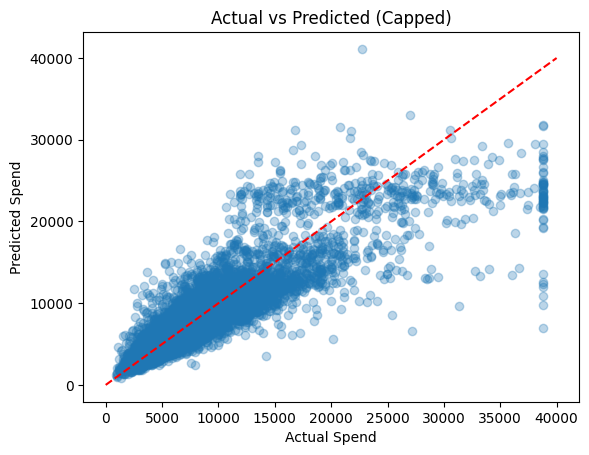

In [56]:
plt.scatter(y_vel_actual, y_pred_actual, alpha=0.3)
plt.plot([0, 40000], [0, 40000], color='red', linestyle='--')
plt.xlabel('Actual Spend')
plt.ylabel('Predicted Spend')
plt.title('Actual vs Predicted (Capped)')
plt.show()

In [57]:
best_model.feature_importances_

array([4.69391417e-04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.51643815e-03, 2.76807292e-04, 5.26056325e-04,
       6.69167903e-05, 1.42492651e-05, 9.90642453e-05, 7.09675694e-06,
       8.27852163e-01, 1.65470819e-01, 2.09028967e-04, 5.75271227e-04,
       3.12911496e-04, 7.23384799e-04, 5.30916553e-04, 3.57815128e-04,
       5.27435244e-04, 3.77106865e-04, 0.00000000e+00, 3.66848561e-06,
       4.69455491e-06, 1.21529177e-05, 1.08242583e-05, 1.59118492e-05,
       2.67439698e-05, 1.31313496e-05])

In [58]:
feat_imp = pd.Series(best_model.feature_importances_, index=x_train_final.columns)
print(feat_imp.nlargest(10))

num__total_spend_credit_cc          0.827852
num__total_spend_debit_cc           0.165471
num__emi_active                     0.001516
num__total_sum_debited_amount       0.000723
num__total_count_debit_trans        0.000575
num__total_sum_credited_amount      0.000531
num__total_count_credited_counts    0.000527
num__Emp_Tenure_Years               0.000526
num__card_lim                       0.000469
num__total_max_credited_amount      0.000377
dtype: float64


In [59]:
# Select only the important columns
top_features = feat_imp.nlargest(5).index
x_train_reduced = x_train_final[top_features]
x_test_reduced = x_test_final[top_features]

# Re-train the best_model on the reduced data
best_model.fit(x_train_reduced, y_train)

,loss,'squared_error'
,learning_rate,0.01
,n_estimators,500
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [60]:
# 1. Make predictions using the REDUCED feature set
y_pred_log_reduced = best_model.predict(x_test_reduced)

# 2. Inverse log transform
y_val_actual = np.expm1(y_vel)
y_pred_actual_reduced = np.expm1(y_pred_log_reduced)

# 3. Calculate metrics
rmse_reduced = np.sqrt(mean_squared_error(y_vel_actual, y_pred_actual_reduced))
rmse_perc_reduced = (rmse_reduced / y_vel_actual.mean()) * 100

print(f"--- Reduced Feature Model Results ---")
print(f"New RMSE: {rmse_reduced:.2f}")
print(f"New RMSE Percentage: {rmse_perc_reduced:.2f}%")

--- Reduced Feature Model Results ---
New RMSE: 3424.60
New RMSE Percentage: 37.13%


# Predication part

 * Here we are going prediction credit consumption expenditure of the credit missing data
 

In [61]:
# Here we are going tranform Features of the credit missing dataset 

x_input  = preprocessor.transform(credit_missing)

# here x_input final will be frame in dataframe 
x_df  = pd.DataFrame(x_input , columns=preprocessor.get_feature_names_out())

# x variable - features 
x_final = x_df[top_features]

In [62]:
# Model prediction parts 

prediction_log = best_model.predict(x_final)

In [63]:
final_cons = np.expm1(prediction_log)

In [64]:
# here we are save answer sheet into DataFrame

submissin  = pd.DataFrame({
    'ID' : credit_missing['ID'],
    'cc_cons' : final_cons })

submissin.to_csv('final_credit_card.csv' , index =False)
print("predict dataset is save , model is complete")

predict dataset is save , model is complete


# comparsion of actual vs predict of credit_consumption_expenditure_prediction

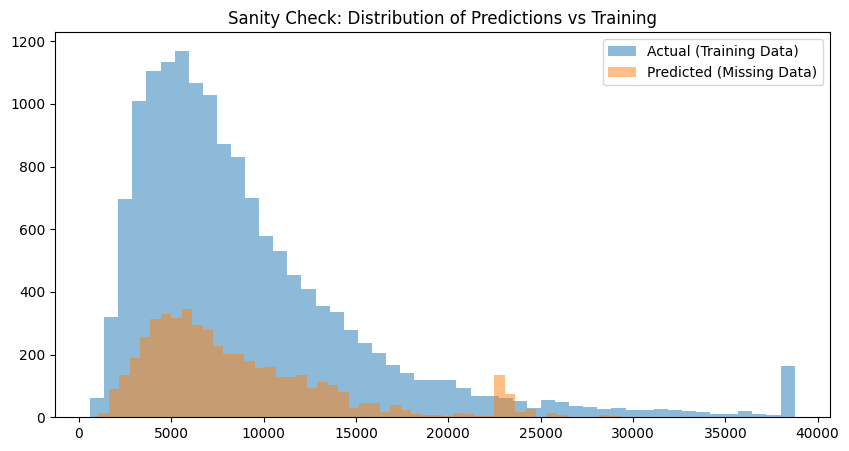

In [65]:
# Compare the distribution of your predictions vs training
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(credit_cc['cc_cons'], bins=50, alpha=0.5, label='Actual (Training Data)')
plt.hist(submissin['cc_cons'], bins=50, alpha=0.5, label='Predicted (Missing Data)')
plt.legend()
plt.title('Sanity Check: Distribution of Predictions vs Training')
plt.show()